In [7]:
import pandas as pd
import xarray as xr

from utils.cfd_functions_post import read_foam_points, read_foam_faces_quad, read_foam_label_list, read_foam_internal_scalar, list_time_dirs, get_patch_faces_and_owner_cells, get_cell_centers, get_run_up_sim, get_free_surface

In [10]:
a,b = get_free_surface('/lustre/geocean/WORK/users/alonsoap/personal/estancia_NUS_2026/HyCFD/trash/case_test', deltaX=0.2)

In [11]:
a

array([ 0.,  5., 10., 15., 20., 25., 30., 35., 40., 45., 50.])

In [12]:
b

<xarray.Dataset> Size: 264kB
Dimensions:       (time: 11, x: 2749)
Coordinates:
  * time          (time) float64 88B 0.0 5.0 10.0 15.0 ... 35.0 40.0 45.0 50.0
  * x             (x) float64 22kB 0.275 0.475 0.675 0.875 ... 549.5 549.7 549.9
Data variables:
    free_surface  (time, x) float64 242kB 0.0 0.0 0.0 0.0 ... nan nan nan nan

MovieWriter ffmpeg unavailable; using Pillow instead.


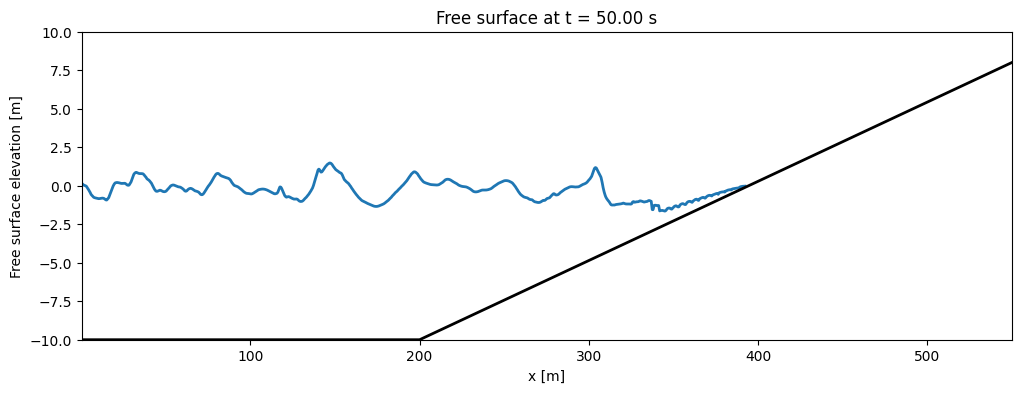

In [14]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

# Your xarray DataArray
fs = b.free_surface  # shape: (time, x)
x = fs.x.values
times = fs.time.values

profile = np.array([
    [0, -10],
    [200, -10],
    [550, 8],
    [550, 8]
])

bx = profile[:,0]
by = profile[:,1]

# Create figure and line
fig, ax = plt.subplots(figsize=(12,4))
line, = ax.plot([], [], lw=2)

ax.plot(bx, by, color="black", lw=2, label="Bathymetry")

ax.set_xlim(x.min(), x.max())
ax.set_ylim(-10,10)
ax.set_xlabel("x [m]")
ax.set_ylabel("Free surface elevation [m]")
ax.set_title("Free surface evolution")


# Update function
def update(frame):
    y = fs.values[frame, :]
    line.set_data(x, y)
    ax.set_title(f"Free surface at t = {times[frame]:.2f} s")
    return line,

# Create animation
anim = FuncAnimation(fig, update, frames=len(times), interval=50, blit=True)

# Or save as mp4
anim.save("free_surface_animation.gif", fps=20, dpi=200)

In [6]:
read_foam_points('/nfs/home/geocean/alonsoap/projects/HyCFD/outputs/openfoam_cases/0000/constant/polyMesh/points')


array([[ 0.00000000e+00, -1.50000000e+01,  0.00000000e+00],
       [ 2.02429150e+00, -1.50000000e+01,  0.00000000e+00],
       [ 4.04858300e+00, -1.50000000e+01,  0.00000000e+00],
       ...,
       [ 1.19595455e+03,  2.75000000e+01,  1.00000000e-01],
       [ 1.19797727e+03,  2.75000000e+01,  1.00000000e-01],
       [ 1.20000000e+03,  2.75000000e+01,  1.00000000e-01]])

In [7]:
read_foam_faces_quad('/nfs/home/geocean/alonsoap/projects/HyCFD/outputs/openfoam_cases/0000/constant/polyMesh/faces')

array([[     1,    249,   3969,   3721],
       [   248,   3968,   3969,    249],
       [     2,    250,   3970,   3722],
       ...,
       [104410, 104411, 104455, 104454],
       [104454, 104455, 104499, 104498],
       [104498, 104499, 104543, 104542]])

In [8]:
read_foam_label_list('/nfs/home/geocean/alonsoap/projects/HyCFD/outputs/openfoam_cases/0000/constant/polyMesh/owner')

array([    0,     0,     1, ..., 51502, 51546, 51590])

In [9]:
read_foam_label_list('/nfs/home/geocean/alonsoap/projects/HyCFD/outputs/openfoam_cases/0000/constant/polyMesh/neighbour')

array([    1,   247,     2, ..., 51588, 51589, 51590])

In [10]:
alpha = read_foam_internal_scalar('/nfs/home/geocean/alonsoap/projects/HyCFD/outputs/openfoam_cases_backup/0000/0/alpha.water',51591)

In [11]:
list_time_dirs('/nfs/home/geocean/alonsoap/projects/HyCFD/outputs/openfoam_cases_backup/0000')

['0',
 '0.5',
 '1',
 '1.5',
 '2',
 '2.5',
 '3',
 '3.5',
 '4',
 '4.5',
 '5',
 '5.5',
 '6',
 '6.5',
 '7',
 '7.5',
 '8',
 '8.5',
 '9',
 '9.5',
 '10',
 '10.5',
 '11',
 '11.5',
 '12',
 '12.5',
 '13',
 '13.5',
 '14',
 '14.5',
 '15',
 '15.5',
 '16',
 '16.5',
 '17',
 '17.5',
 '18',
 '18.5',
 '19',
 '19.5',
 '20',
 '20.5',
 '21',
 '21.5',
 '22',
 '22.5',
 '23',
 '23.5',
 '24',
 '24.5',
 '25',
 '25.5',
 '26',
 '26.5',
 '27',
 '27.5',
 '28',
 '28.5',
 '29',
 '29.5',
 '30',
 '30.5',
 '31',
 '31.5',
 '32',
 '32.5',
 '33',
 '33.5',
 '34',
 '34.5',
 '35',
 '35.5',
 '36',
 '36.5',
 '37',
 '37.5',
 '38',
 '38.5',
 '39',
 '39.5',
 '40',
 '40.5',
 '41',
 '41.5',
 '42',
 '42.5',
 '43',
 '43.5',
 '44',
 '44.5',
 '45',
 '45.5',
 '46',
 '46.5',
 '47',
 '47.5',
 '48',
 '48.5',
 '49',
 '49.5',
 '50',
 '50.5',
 '51',
 '51.5',
 '52',
 '52.5',
 '53',
 '53.5',
 '54',
 '54.5',
 '55',
 '55.5',
 '56',
 '56.5',
 '57',
 '57.5',
 '58',
 '58.5',
 '59',
 '59.5',
 '60',
 '60.5',
 '61',
 '61.5',
 '62',
 '62.5',
 '63',
 '63.

In [12]:
a,b = get_patch_faces_and_owner_cells('/nfs/home/geocean/alonsoap/projects/HyCFD/outputs/openfoam_cases_backup/0000/constant/polyMesh','bottom')

In [13]:
import numpy as np

def select_patch_cells(mesh_dir, patch_name, zC, yC, y_min_phys=None, tol_z=1e-6):

    # --- Middle z-plane (optional thin slice) ---
    z_mid = np.median(zC)
    keep2D = np.abs(zC - z_mid) < tol_z

    # --- Get patch faces and owner cells ---
    patch_face_ids, patch_owner_cells = get_patch_faces_and_owner_cells(mesh_dir, patch_name)

    # Unique patch cells
    patch_cells = np.unique(patch_owner_cells)  # already 0-based in Python

    # Keep only middle z-layer
    patch_cells = patch_cells[keep2D[patch_cells]]

    # Restrict by minimum y if specified
    if y_min_phys is not None and np.isfinite(y_min_phys):
        patch_cells = patch_cells[yC[patch_cells] >= y_min_phys]

    return patch_cells


In [14]:
t, ru, ru2 = get_run_up_sim(case_dir = '/nfs/home/geocean/alonsoap/projects/HyCFD/outputs/openfoam_cases_backup/0000')

In [15]:
ru2

4.619601648

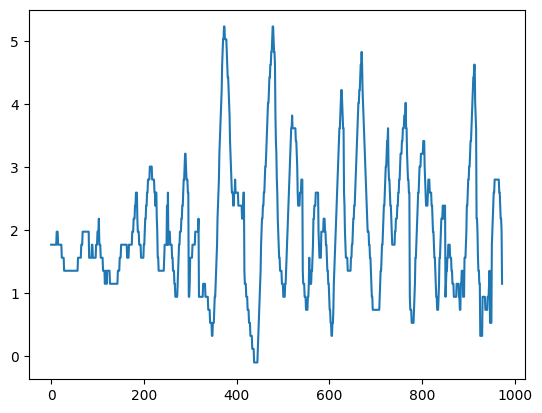

In [16]:
import matplotlib.pyplot as plt
plt.plot(ru)

In [17]:
xC, yC, zC, n_cells = get_cell_centers('/nfs/home/geocean/alonsoap/projects/HyCFD/outputs/openfoam_cases_backup/0000/constant/polyMesh')

ValueError: 'c' argument has 51591 elements, which is inconsistent with 'x' and 'y' with size 593.

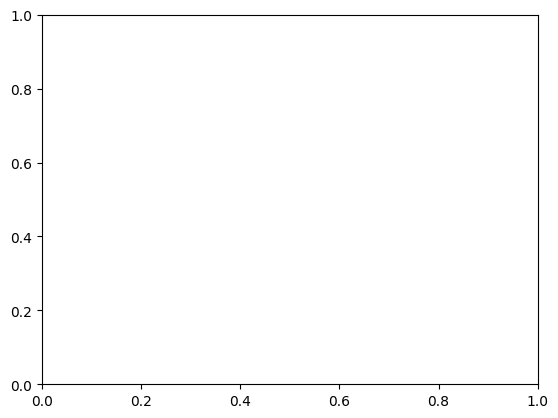

In [18]:
import matplotlib.pyplot as plt
plt.scatter(xC[[b]],yC[[b]],c=alpha)